Loaded data from: data\processed\train_merged.parquet
<class 'pandas.DataFrame'>
RangeIndex: 1277860 entries, 0 to 1277859
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   building_id         1277860 non-null  int64         
 1   meter               1277860 non-null  int64         
 2   timestamp           1277860 non-null  datetime64[us]
 3   meter_reading       1277860 non-null  float64       
 4   site_id             1277860 non-null  int64         
 5   primary_use         1277860 non-null  str           
 6   square_feet         1277860 non-null  int64         
 7   year_built          1048452 non-null  float64       
 8   floor_count         225215 non-null   float64       
 9   air_temperature     1277860 non-null  float64       
 10  cloud_coverage      761414 non-null   float64       
 11  dew_temperature     1277860 non-null  float64       
 12  precip_depth_1_hr   1049405

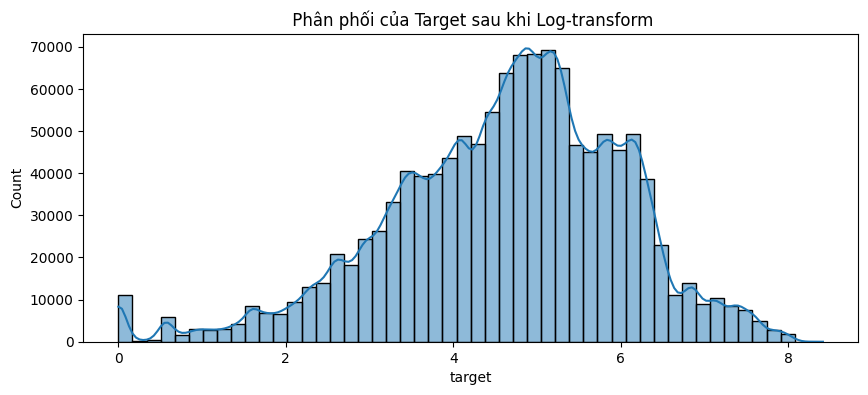

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
candidates = [
    Path("data/process/train_merged.parquet"),
    Path("data/processed/train_merged.parquet"),
    Path("data/train_merged.parquet"),
]

for path in candidates:
    if path.exists():
        df = pd.read_parquet(path)
        print(f"Loaded data from: {path}")
        break
else:
    raise FileNotFoundError(
        "Could not find 'train_merged.parquet'. Checked:\n- "
        + "\n- ".join(str(p) for p in candidates)
    )
df.info()
print(df.head())
df['timestamp']=pd.to_datetime(df['timestamp'])

# Remove dirty readings at site 0 during Train months (May- Sep)
if 'site_id' in df.columns:
    dirty_mask = (
        (df['site_id'] == 0)
        & (df['meter_reading'] == 0)
        & (df['timestamp'].dt.month.between(5, 9))
    )
    df = df.loc[~dirty_mask].copy()
else:
    print("Warning: 'site_id' not found; skipping dirty-data removal")

# Log-transform target
df['target']=np.log1p(df['meter_reading'])
plt.figure(figsize=(10,4))
sns.histplot(df['target'],bins=50,kde=True)
plt.title(" Phân phối của Target sau khi Log-transform")
df['hour']=df['timestamp'].dt.hour
df['dayofweek']=df['timestamp'].dt.dayofweek
df['is_weekend']=(df['dayofweek']>=5).astype(int)
train_df=df[df['timestamp'].dt.month.between(5,9)].copy()
valid_df=df[df['timestamp'].dt.month==10].copy()
print(f"Số lượng mẫu tập Train ( Tháng 5-9 ): {train_df.shape[0]}")
print(f"Số lượng mẫu tập Valid ( Tháng 10 ): {valid_df.shape[0]}")
print(f"Ngày cuối của Train: {train_df['timestamp'].max()}")
print(f"Ngày đầu của Valid: {valid_df['timestamp'].min()}")


In [ ]:
# Feature selection + preprocessing pipeline (fixed and runnable)
num_features=['square_feet','air_temperature','dew_temperature','hour','dayofweek','is_weekend']
cat_features=['primary_use','site_id']
X_train=train_df[num_features+cat_features].copy()
y_train=train_df['target'].copy()
X_valid=valid_df[num_features+cat_features].copy()
y_valid=valid_df['target'].copy()

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])
# robust OneHotEncoder instantiation to support multiple sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
cat_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot', ohe),
])
preprocessor=ColumnTransformer([
    ('num',num_pipeline,num_features),
    ('cat',cat_pipeline,cat_features),
], remainder='drop')

full_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model', RandomForestRegressor(n_estimators=50, max_depth=15, n_jobs=-1, random_state=42))
])

# Fit and evaluate (RMSE on log-target). Also compute original-scale RMSE via expm1
full_pipeline.fit(X_train, y_train)
train_pred = full_pipeline.predict(X_train)
valid_pred = full_pipeline.predict(X_valid)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
print(f'Train RMSE (log-target): {train_rmse:.4f}')
print(f'Valid RMSE (log-target): {valid_rmse:.4f}')
# Back-transform to original scale (guarded)
try:
    train_rmse_orig = np.sqrt(mean_squared_error(np.expm1(y_train), np.expm1(train_pred)))
    valid_rmse_orig = np.sqrt(mean_squared_error(np.expm1(y_valid), np.expm1(valid_pred)))
    print(f'Train RMSE (original): {train_rmse_orig:.4f}')
    print(f'Valid RMSE (original): {valid_rmse_orig:.4f}')
except Exception as e:
    print('Could not compute original-scale RMSE:', e)
